# Phase 1: Quantitative Core Engine & Parametric Extraction
This section handles historical market data acquisition for JPMorgan Chase & Co. (JPM), estimates the statistical parameters (drift $\mu$ and volatility $\sigma$), and executes the stochastic simulation derived via Itô's Lemma.

### Methodological Framework: Geometric Brownian Motion (GBM)
The discrete price dynamics are governed by the analytical solution of the stochastic differential equation (SDE):

$$S_t = S_0 \exp\left(\left(\mu - \frac{1}{2}\sigma^2\right)t + \sigma W_t\right)$$

*   **$S_0$**: Initial asset baseline price (\$341.10).
*   **$\mu$**: Drift coefficient representing average daily return.
*   **$\sigma$**: Asset volatility calculated from standard deviation.
*   **$\frac{1}{2}\sigma^2$**: Volatility drag correction factor.
*   **$W_t$**: Random shocks generated via standard normal distribution.

In [25]:
# --- Import Libraries --- #
import numpy as np
import pandas as pd
import yfinance as yf
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

In [36]:
# Set random seed for reproducibility of the Monte Carlo simulation
np.random.seed(17)

# --- 1. DATA ACQUISITION & PARAMETER EXTRACTION --- #

ticker = "JPM"
df = yf.download(ticker, period="1y")

# Clean multi-index columns if present in newer yfinance versions
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.droplevel(1)

# Calculate daily log-like percentage returns
df['Returns'] = df['Close'].pct_change()

# Calculate historical baseline statistics (daily drift and volatility)
mu = df['Returns'].mean()     # Drift (historical average daily return)
sigma = df['Returns'].std()  # Volatility (historical daily standard deviation)

# Extract the latest closing price as the simulation starting point (S0)
S0 = float(df['Close'].iloc[-1])

# --- 2. MONTE CARLO ENGINE (GBM via Itô's Lemma) --- #

t_intervals = 252  # Time horizon: 1 trading year (~252 trading days)
iterations = 10000 # Number of independent simulated price paths

# Generate a matrix of daily growth factors based on Geometric Brownian Motion (GBM)
random_shocks = np.random.standard_normal((t_intervals, iterations))
daily_growth = np.exp((mu - 0.5 * sigma ** 2) + sigma * random_shocks)

# Initialize and fill the price compounding matrix
price_list = np.zeros_like(daily_growth)
price_list[0] = S0

for t in range(1, t_intervals):
    price_list[t] = price_list[t - 1] * daily_growth[t]

# --- 3. RISK MEASUREMENT & METRICS OUTPUT --- #

simulated_returns = (price_list[-1] - S0) / S0
var_95 = np.percentile(simulated_returns, 5)

portfolio_value = 10000
potential_loss = abs(var_95) * portfolio_value

print("=" * 62)
print("     MONTE CARLO VaR FOR JPMORGAN CHASE CO.   ")
print("=" * 62)
print(f"Initial Asset Price (S0)   : ${S0:,.2f}")
print(f"Simulation Horizon         : {t_intervals} Trading Days (1 Year)")
print(f"VaR 95% Confidence Level   : {var_95 * 100:.2f}%")
print(f"Parametric Exposure Loss   : ${potential_loss:,.2f} (Per ${portfolio_value:,} Portfolio)")
print("=" * 62)

[*********************100%***********************]  1 of 1 completed

     MONTE CARLO VaR FOR JPMORGAN CHASE CO.   
Initial Asset Price (S0)   : $341.10
Simulation Horizon         : 252 Trading Days (1 Year)
VaR 95% Confidence Level   : -16.59%
Parametric Exposure Loss   : $1,658.73 (Per $10,000 Portfolio)


# Phase 2.1: Stochastic Price Trajectories (Spaghetti Path Analysis)
This section visualizes the time-series evolution of the simulated asset pathways over the $252$-trading-day horizon. 

### Visual Characteristics:
*   **Convergence at Base ($t=0$):** All trajectories launch from the identical localized node ($S_0 = \$341.10$).
*   **Geometric Dispersion:** As time $t$ progresses, the compounding random walk expands the variance, illustrating the accelerating systemic uncertainty over the long-term forecast window.

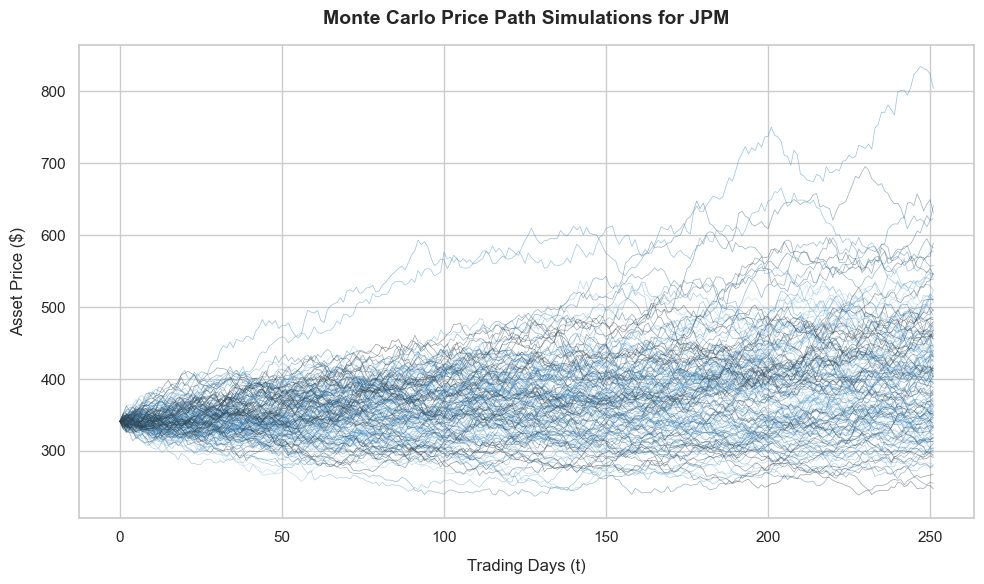

In [38]:
# --- VISUALIZATION: STOCHASTIC PRICE TRAJECTORIES --- #

# Set the visual style to match the distribution plot
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))

colors = sns.color_palette("Blues_d", n_colors=150)

# Plot a subset of 150 trajectories with fading colors
for i in range(150):
    plt.plot(price_list[:, i], lw=0.5, alpha=0.5, color=colors[i])

# Typography and labels
plt.title("Monte Carlo Price Path Simulations for JPM", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Trading Days (t)", fontsize=12, labelpad=10)
plt.ylabel("Asset Price ($)", fontsize=12, labelpad=10)

plt.tight_layout()

# Save the plot as static image
plt.savefig("jpm_monte_carlo_trajectories.png", dpi=300)

plt.show()

### Phase 2.2: Interactive Simulation Animation (Local Rendering)
This block generates an animated visualization of the stochastic price pathways, tracking the day-by-day evolution of the asset's simulated returns. 

Executing this cell will invoke the `matplotlib.animation` engine to render the trajectories. The final output is saved locally as `jpm_monte_carlo.gif` in your working directory. This workflow is designed to provide dynamic visual insights into tail-risk progression and path-dependent volatility without requiring external dependencies beyond the standard scientific stack.

In [37]:
# Set theme
sns.set_theme(style="whitegrid")

# Setup the figure and axis limits
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_xlim(0, t_intervals)
sampled_paths = price_list[:, :100]
ax.set_ylim(np.min(sampled_paths) * 0.9, np.max(sampled_paths) * 1.1)

# Set labels and title
ax.set_title("Monte Carlo Price Path Simulations for JPM", fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Trading Days (t)", fontsize=12, labelpad=10)
ax.set_ylabel("Asset Price ($)", fontsize=12, labelpad=10)

# Generate a color palette for the lines
colors = sns.color_palette("Blues_d", n_colors=100)

# Initialize 100 empty line objects
lines = [ax.plot([], [], lw=0.7, alpha=0.6, color=colors[i])[0] for i in range(100)]

# Initialization function: plots the background of each frame
def init():
    for line in lines:
        line.set_data([], [])
    return lines

# Animation function: called sequentially to update the data for each frame
def update(frame):
    # 'frame' corresponds to the current day 't' (from 1 to 252)
    t_axis = np.arange(frame + 1)
    for i, line in enumerate(lines):
        # Update each line with data up to the current frame day
        line.set_data(t_axis, sampled_paths[:frame + 1, i])
    return lines

# Create the animation object
ani = FuncAnimation(fig, update, frames=t_intervals, init_func=init, blit=True, interval=20)

plt.close()

# Save the animation as a GIF file
ani.save('jpm_monte_carlo.gif', writer='pillow', fps=30)

# Display the animation directly inside Jupyter Notebook as a video player
HTML(ani.to_html5_video())

# Phase 3: Empirical Terminal Return Distribution & Tail Risk Cut-off
This section plots the probability density functions of the final returns matrix at maturity. It maps the empirical boundary of extreme capital risks.

### Statistical Properties & Risk Interpretations:
*   **Lognormal Skewness:** The distribution exhibits a distinct **positive (right) skewness**, demonstrating the structural asymmetry of asset returns (bounded maximum downside loss at $-100\%$ against mathematically infinite upside compounding potential).
*   **Value at Risk Definition ($\text{VaR}_{95\%}$):** The red dashed line marks the **5th percentile threshold ($-16.59\%$)**. We state with $95\%$ statistical confidence that the maximum portfolio erosion will not exceed $16.59\%$ over the 1-year horizon.

### Financial Interpretation of the JPM Monte Carlo VaR:

1. **Downside Risk Capital Boundary:** 
   At a 95% confidence level, the maximum expected capital erosion for JPMorgan Chase & Co. (JPM) over a 252-trading-day horizon is **16.59%**. This means we are 95% statistically confident that the maximum loss will not exceed this threshold under normal market conditions.

2. **Tail Risk Domain (The 5% Exception):** 
   Conversely, there is a structural 5% probability (representing extreme tail events or systemic market shocks) that the annual portfolio loss could exceed 16.59%. In institutional risk management, this tail region requires further stress testing and Expected Shortfall (ES) mapping to capture non-linear black swan risks.

3. **Absolute Portfolio Capital Allocation:** 
   For an institutional baseline position of **$10,000**, the absolute maximum dollar exposure at risk (Dollar VaR) is precisely **$1,658.73**. This metric directly dictates the required economic capital buffers and regulatory reserves under Basel framework guidelines to prevent insolvency during adverse market cycles.

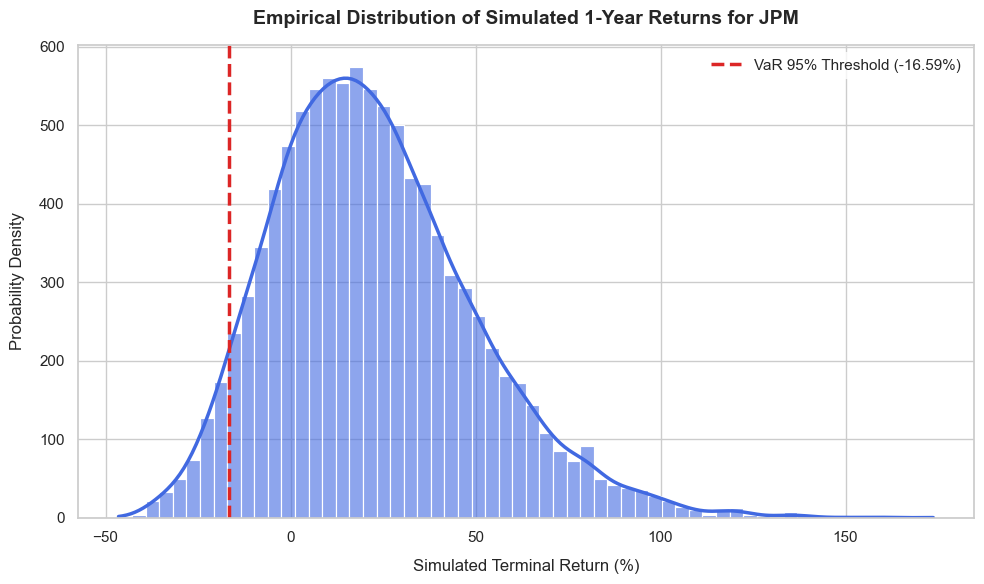

In [ ]:
# --- VISUALIZATION: TERMINAL RETURN DISTRIBUTION --- #

# Set the visual style
sns.set_theme(style="whitegrid", palette="muted")

plt.figure(figsize=(10, 6))

# Plot the distribution using Seaborn's histplot
sns.histplot(
    x=simulated_returns * 100, 
    bins=60, 
    kde=True, 
    color="royalblue", 
    edgecolor="white", 
    alpha=0.6,
    line_kws={"linewidth": 2.5, "color": "#1a365d"}
)

# Add a vertical line to mark the 95% Value at Risk threshold
plt.axvline(
    x=var_95 * 100, 
    color="#dc2626",
    linestyle="--", 
    linewidth=2.5, 
    label=f'VaR 95% Threshold ({var_95 * 100:.2f}%)'
)

# Chart typography and labels
plt.title("Empirical Distribution of Simulated 1-Year Returns for JPM", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Simulated Terminal Return (%)", fontsize=12, labelpad=10)
plt.ylabel("Probability Density", fontsize=12, labelpad=10)

plt.legend(loc='upper right', fontsize=11, frameon=True, facecolor='white', edgecolor='none')
plt.tight_layout()

plt.show()